# Use scRICH CCC signaling modes as input for external CCC inference method

In this tutorial, we discuss how the CCC signaling modes identified via scRICH can be used as input to infer a CCC matrix using an externbal package. For this tutorial, we will use [LIANA+](https://liana-py.readthedocs.io/en/latest/), but the concept can be externded to other packages.

For this tutorial, we will consider a human dataset because LIANA+ naturally supports a human ligand/receptor databases. The approach can be extended to mouse data via LIANA+'s [homology mapping](https://liana-py.readthedocs.io/en/latest/notebooks/prior_knowledge.html#Homology-Mapping). Specifically, we will use the skin-derived organoid dataset used in Fig. 3 of the paper. This dataset is available in scRICH's github repository to reproduce this notebook.

### 0-Package import

In [1]:
import scvelo as scv
import scanpy as sc
import os
import string
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
import scrich as ri

import liana as li
# from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean, rank_aggregate

In [2]:
import warnings
warnings.simplefilter("ignore", DeprecationWarning)

### 1-Load data and evaluate a CCC pathway

This dataset already includes the initial CCC pathway analysis showed in Tutorial-1, as seen by the keys in the adata.obs() dataframe.

In [3]:
adata = sc.read_h5ad('datasets/FibHSE_analyzed_moments.h5ad')

In [4]:
adata.obs.keys()

Index(['orig.ident', 'nCount_spliced', 'nFeature_spliced', 'nCount_unspliced',
       'nFeature_unspliced', 'nCount_ambiguous', 'nFeature_ambiguous',
       'spliced_snn_res.0.8', 'seurat_clusters', 'replicate',
       ...
       'SEMA7_modes', 'KIT_rec', 'KIT_lig', 'KIT_modes', 'EPHB_rec',
       'EPHB_lig', 'EPHB_modes', 'VCAM_rec', 'VCAM_lig', 'VCAM_modes'],
      dtype='object', length=135)

We focus specifically on the EGF CCC pathway:

In [5]:
adata.uns['pathways']['EGF']

{'cci_heterogeneity': array([0.52432055, 0.94259041, 0.91319071, 0.54485347, 0.70570527,
        0.574309  , 0.716206  , 0.41065311, 0.77078177, 0.30833647,
        0.918916  , 1.        ]),
 'ligands': array(['EGF', 'HBEGF', 'TGFA', 'BTC', 'EREG', 'AREG'], dtype=object),
 'receptors': array(['ERBB2', 'ERBB4', 'EGFR'], dtype=object)}

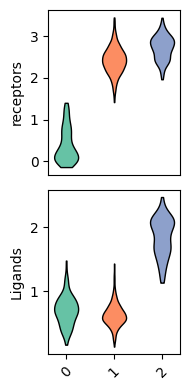

In [6]:
ri.pl.mode_violin(adata, 'EGF_modes', savefig=False, showfig=True)

Based on these profiles, we label the EGF CCC signaling modes as weak, receiver, and sender/receiver states.

In [7]:
ri.tl.rename_modes(adata, 'EGF', {0: 'Weak', 1: 'Receiver', 2: 'Sender/Receiver'})

### 2-Run LIANA+'s CCC inference

Now, we run LIANA+'s [steady state inference method](https://liana-py.readthedocs.io/en/latest/notebooks/basic_usage.html) using the EGF CCC labels rather than the cell type annotations.

In [18]:
adata.obs['EGF_modes']

AAACCCAGTGATACCT-1_3           Receiver
AAACCCATCTTAGCAG-1_3           Receiver
AAACGCTTCTATGCCC-1_3           Receiver
AAAGAACAGAGGTTTA-1_3           Receiver
AAAGAACGTACTCGTA-1_3    Sender/Receiver
                             ...       
TTTACTGCACGGGCTT-1_4               Weak
TTTCATGTCATTTCGT-1_4               Weak
TTTCCTCTCGAAGCAG-1_4               Weak
TTTCGATGTAGTCCTA-1_4           Receiver
TTTGATCGTAGACGGT-1_4               Weak
Name: EGF_modes, Length: 1509, dtype: object

We run the "aggregate" method, which is a consensus of several CCC inference methods. Users have options to run individual methods following LIANA+'s original tutorial and documentation.

In [21]:
li.method.rank_aggregate(adata, groupby='EGF_modes', key_added='aggregate')

In [41]:
adata.uns['aggregate'].head()

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
169,Receiver,Receiver,GSTP1,EGFR,2.281546,0.000,3.232135,0.202728,0.230967,0.164506,0.922956,0.058643,0.000148
1193,Sender/Receiver,Receiver,GSTP1,EGFR,2.132920,0.791,2.971506,-0.021826,-0.132727,0.151241,0.919913,0.656881,0.000290
1073,Sender/Receiver,Receiver,ANXA1,EGFR,2.095419,0.000,2.905744,0.664137,0.745973,0.186110,0.919084,0.005905,0.000333
606,Receiver,Sender/Receiver,GSTP1,EGFR,2.159739,0.417,2.334099,-0.004830,0.025492,0.118799,0.910556,0.337357,0.000592
1557,Sender/Receiver,Sender/Receiver,DSC2,DSG3,2.014692,0.000,4.053275,1.239888,1.236452,0.260500,0.930629,0.000394,0.000592


It is important to stress that LIANA+ will run the CCC inference model on all ligand-receptor pairs. The cell lableing "EGF_modes" computed by scRICH, however, is meaningful only for the EGF pathway. So, for exmaple, we can select only the interactions that include an EGF ligand from *adata.uns['aggregate'].head()*:

In [42]:
egf_lig, egf_rec = list(adata.uns['pathways']['EGF']['ligands']), list(adata.uns['pathways']['EGF']['receptors'])

In [43]:
egf_interactions = adata.uns['aggregate']
egf_interactions = egf_interactions[ egf_interactions['ligand_complex'].isin(egf_lig) ]

In [44]:
egf_interactions

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
1197,Sender/Receiver,Receiver,HBEGF,CD9,1.366086,0.000,1.397170,0.363266,0.112073,0.192510,0.887340,0.021489,0.010743
1918,Sender/Receiver,Weak,HBEGF,CD9,1.251491,0.001,1.241037,0.195649,0.518259,0.170997,0.881279,0.078911,0.014756
1612,Sender/Receiver,Sender/Receiver,HBEGF,CD9,1.202853,0.160,1.174770,0.124508,-0.036309,0.161867,0.878379,0.280578,0.018089
484,Receiver,Sender/Receiver,AREG,EGFR_ERBB2,1.547944,0.000,0.685122,0.426735,0.307174,0.259316,0.846518,0.004410,0.030040
173,Receiver,Receiver,HBEGF,CD9,1.188327,0.002,0.668023,0.021511,-0.400891,0.092044,0.844869,1.000000,0.034229
2092,Weak,Receiver,HBEGF,CD9,1.170326,0.444,0.594185,-0.013098,0.127976,0.081870,0.837037,1.000000,0.042904
940,Receiver,Weak,HBEGF,CD9,1.073731,1.000,0.593372,-0.146107,0.005295,0.081758,0.836944,1.000000,0.043871
2215,Weak,Sender/Receiver,AREG,EGFR_ERBB2,1.328025,0.987,0.579609,0.203615,0.162947,0.219380,0.835336,0.133444,0.047335
610,Receiver,Sender/Receiver,HBEGF,CD9,1.025094,1.000,0.561688,-0.217248,-0.549273,0.077393,0.833165,1.000000,0.053563
1195,Sender/Receiver,Receiver,HBEGF,CD44,0.943042,0.000,0.820785,0.354861,-0.001858,0.205561,0.857891,0.146569,0.057362


Additionally, we might want to select only receptors from the EGF pathway in the "receptor_complex" column. Here, we encouter the problem that several EGF receptors are reported as complexes (such as *EGFR_ERBB2*), whereas scRICH's analysis is based on expression of individual receptors, as we see from the list of EGF-related receptors:

In [45]:
egf_rec

['ERBB2', 'ERBB4', 'EGFR']

Therefore, depending on the specific circumstance, it might be necessary to aggregate receptors into complexes. If we simply run:

In [46]:
egf_interactions_empty = egf_interactions[ egf_interactions['receptor_complex'].isin(egf_rec) ]
egf_interactions_empty

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank


we obtain an empty dataset. Instead, we select for the receptvor complex implemented in LIANA+'s CCC inference model:

In [47]:
egf_interactions = egf_interactions[ egf_interactions['receptor_complex']=='EGFR_ERBB2' ]
egf_interactions

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
484,Receiver,Sender/Receiver,AREG,EGFR_ERBB2,1.547944,0.000,0.685122,0.426735,0.307174,0.259316,0.846518,0.004410,0.030040
2215,Weak,Sender/Receiver,AREG,EGFR_ERBB2,1.328025,0.987,0.579609,0.203615,0.162947,0.219380,0.835336,0.133444,0.047335
1498,Sender/Receiver,Sender/Receiver,AREG,EGFR_ERBB2,1.192363,1.000,0.514522,0.065979,-0.414496,0.194745,0.826979,1.000000,0.067689
1586,Sender/Receiver,Sender/Receiver,EREG,EGFR_ERBB2,0.715349,0.000,0.285661,1.119087,0.852494,0.476307,0.780769,0.000023,0.239783
53,Receiver,Receiver,AREG,EGFR_ERBB2,1.465641,0.000,0.215003,0.046392,0.101959,0.081378,0.755484,0.550460,0.248879
2030,Weak,Receiver,AREG,EGFR_ERBB2,1.245721,1.000,0.181891,-0.176728,-0.042268,0.068845,0.739709,1.000000,0.357912
1091,Sender/Receiver,Receiver,AREG,EGFR_ERBB2,1.110059,1.000,0.161466,-0.314363,-0.619711,0.061114,0.728079,1.000000,0.477085
1170,Sender/Receiver,Receiver,EREG,EGFR_ERBB2,0.633045,0.000,0.089645,0.738745,0.647279,0.149473,0.666119,0.012926,0.535384
1768,Sender/Receiver,Sender/Receiver,TGFA,EGFR_ERBB2,0.329110,0.000,0.100353,0.555783,0.199812,0.308041,0.678546,0.004410,0.604243
1198,Sender/Receiver,Receiver,HBEGF,EGFR_ERBB2,0.378258,0.000,0.051284,0.283429,0.147899,0.111031,0.601433,0.168505,0.636218


From here, all visualization and downstream analysis implemented in LIANA+ is accessible for this data.